In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Employee_Attrition_DataSet.csv")

In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 14)


,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [106]:
df.drop('EmployeeID', axis=1, inplace=True)

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  int64  
 1   Department             10000 non-null  int64  
 2   JobLevel               10000 non-null  int64  
 3   YearsAtCompany         10000 non-null  int64  
 4   MonthlyIncome          10000 non-null  int64  
 5   JobSatisfaction        10000 non-null  int64  
 6   WorkLifeBalance        10000 non-null  int64  
 7   OverTime               10000 non-null  int64  
 8   DistanceFromHome       10000 non-null  float64
 9   PromotionLast5Years    10000 non-null  int64  
 10  PerformanceRating      10000 non-null  int64  
 11  TrainingHoursLastYear  10000 non-null  int64  
 12  Attrition              10000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 1015.8 KB


In [108]:
df.describe()
    

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.693500,3.263500,2.380800,7.788400,8967.918800,3.362100,2.761500,0.284900,9.91074,0.091400,2.603800,14.993100,0.090300
std,9.376457,2.278374,1.141368,7.141941,3500.745748,1.059951,0.893027,0.451389,6.97463,0.288192,0.737889,3.886227,0.286625
min,22.000000,0.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,0.000000,1.00000,0.000000,1.000000,2.000000,0.000000
25%,31.000000,1.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,0.000000,4.70000,0.000000,2.000000,12.000000,0.000000
50%,37.000000,4.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,0.000000,8.30000,0.000000,3.000000,15.000000,0.000000
75%,44.000000,5.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,1.000000,13.40000,0.000000,3.000000,18.000000,0.000000
max,60.000000,6.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,1.000000,50.00000,1.000000,4.000000,31.000000,1.000000


In [8]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["Attrition"].value_counts()

Attrition
No     9097
Yes     903
Name: count, dtype: int64

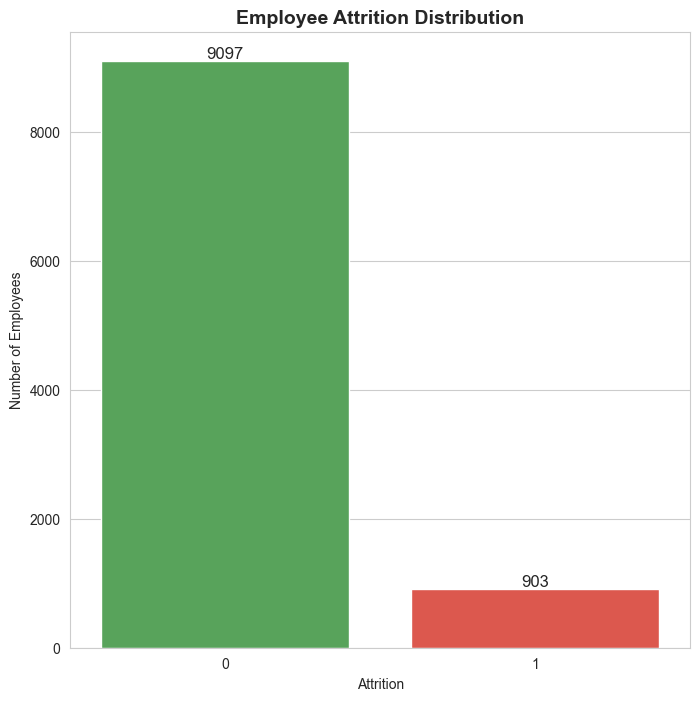

In [109]:
plt.figure(figsize=(8,8))

ax = sns.countplot(
    x="Attrition",
    data=df,
    palette=["#4CAF50", "#F44336"]  
)

#  numbers on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
       
    )

plt.title("Employee Attrition Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

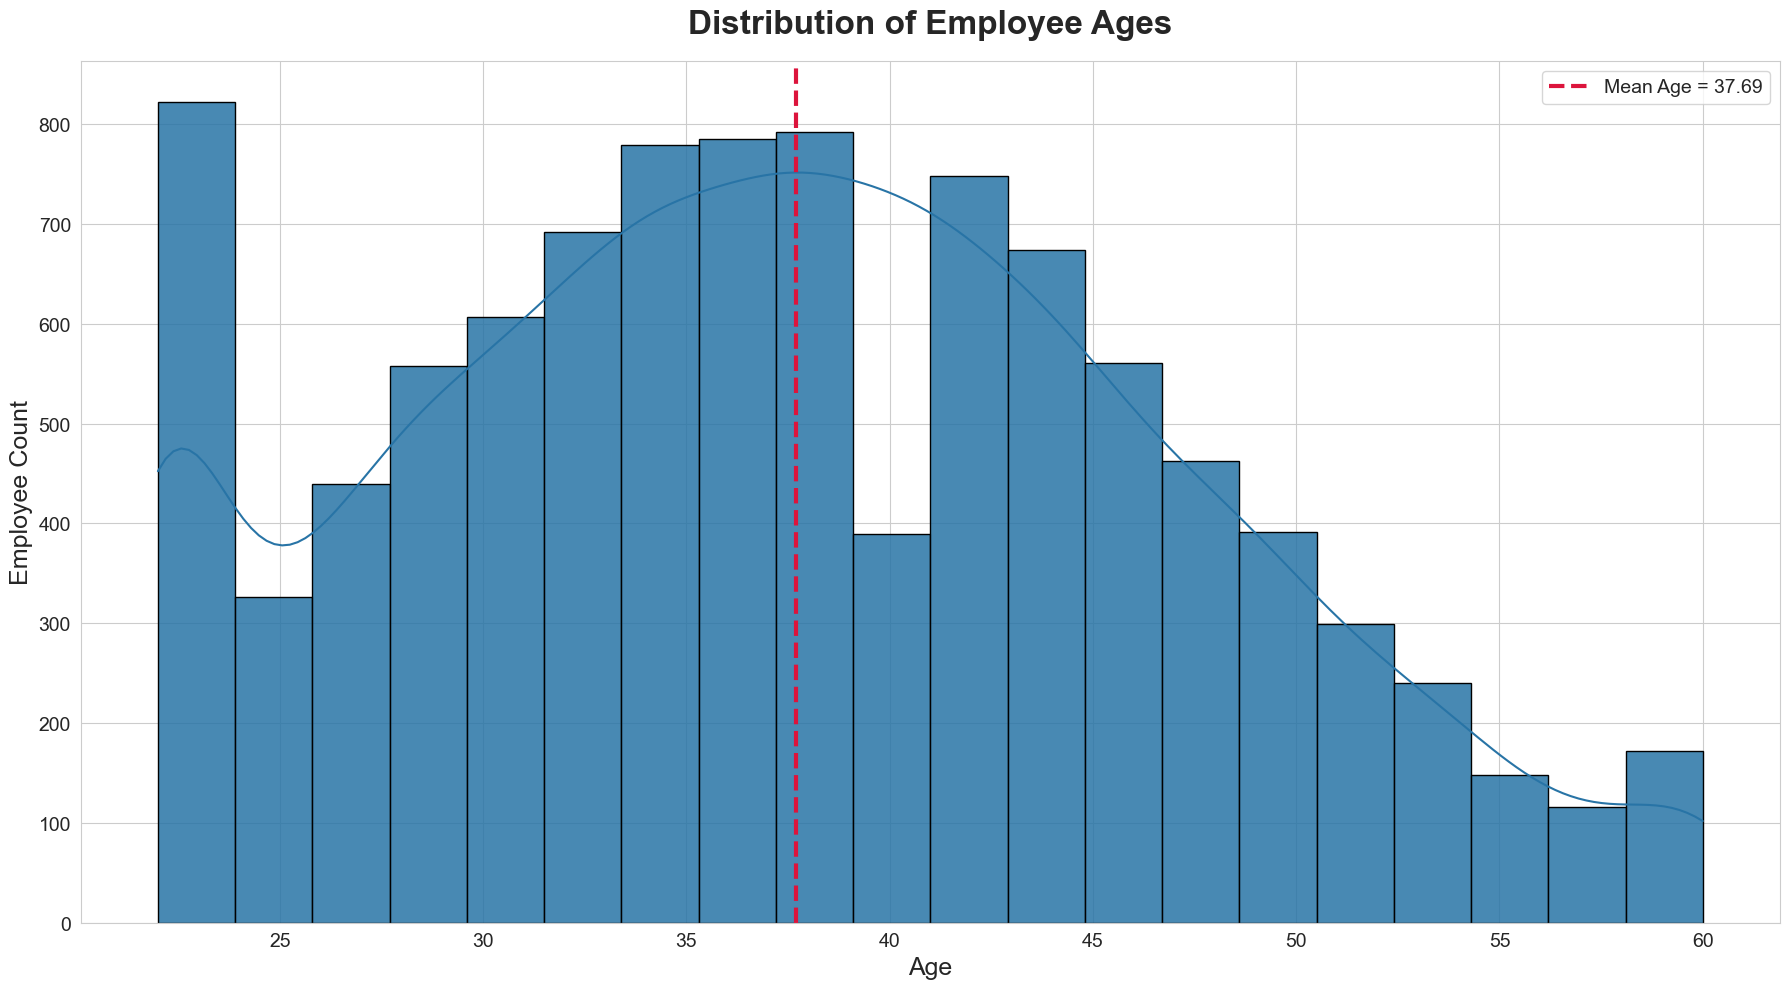

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(18, 10))  # Much larger figure

ax = sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="#2874A6",
    edgecolor="black",
    alpha=0.85
)

mean_age = df["Age"].mean()

plt.axvline(
    mean_age,
    color="crimson",
    linestyle="--",
    linewidth=3,
    label=f"Mean Age = {mean_age:.2f}"
)

plt.title(
    "Distribution of Employee Ages",
    fontsize=24,
    fontweight="bold",
    pad=20
)
plt.xlabel("Age", fontsize=18)
plt.ylabel("Employee Count", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [112]:
import pandas as pd

df['A'].mean()


np.float64(37.6935)

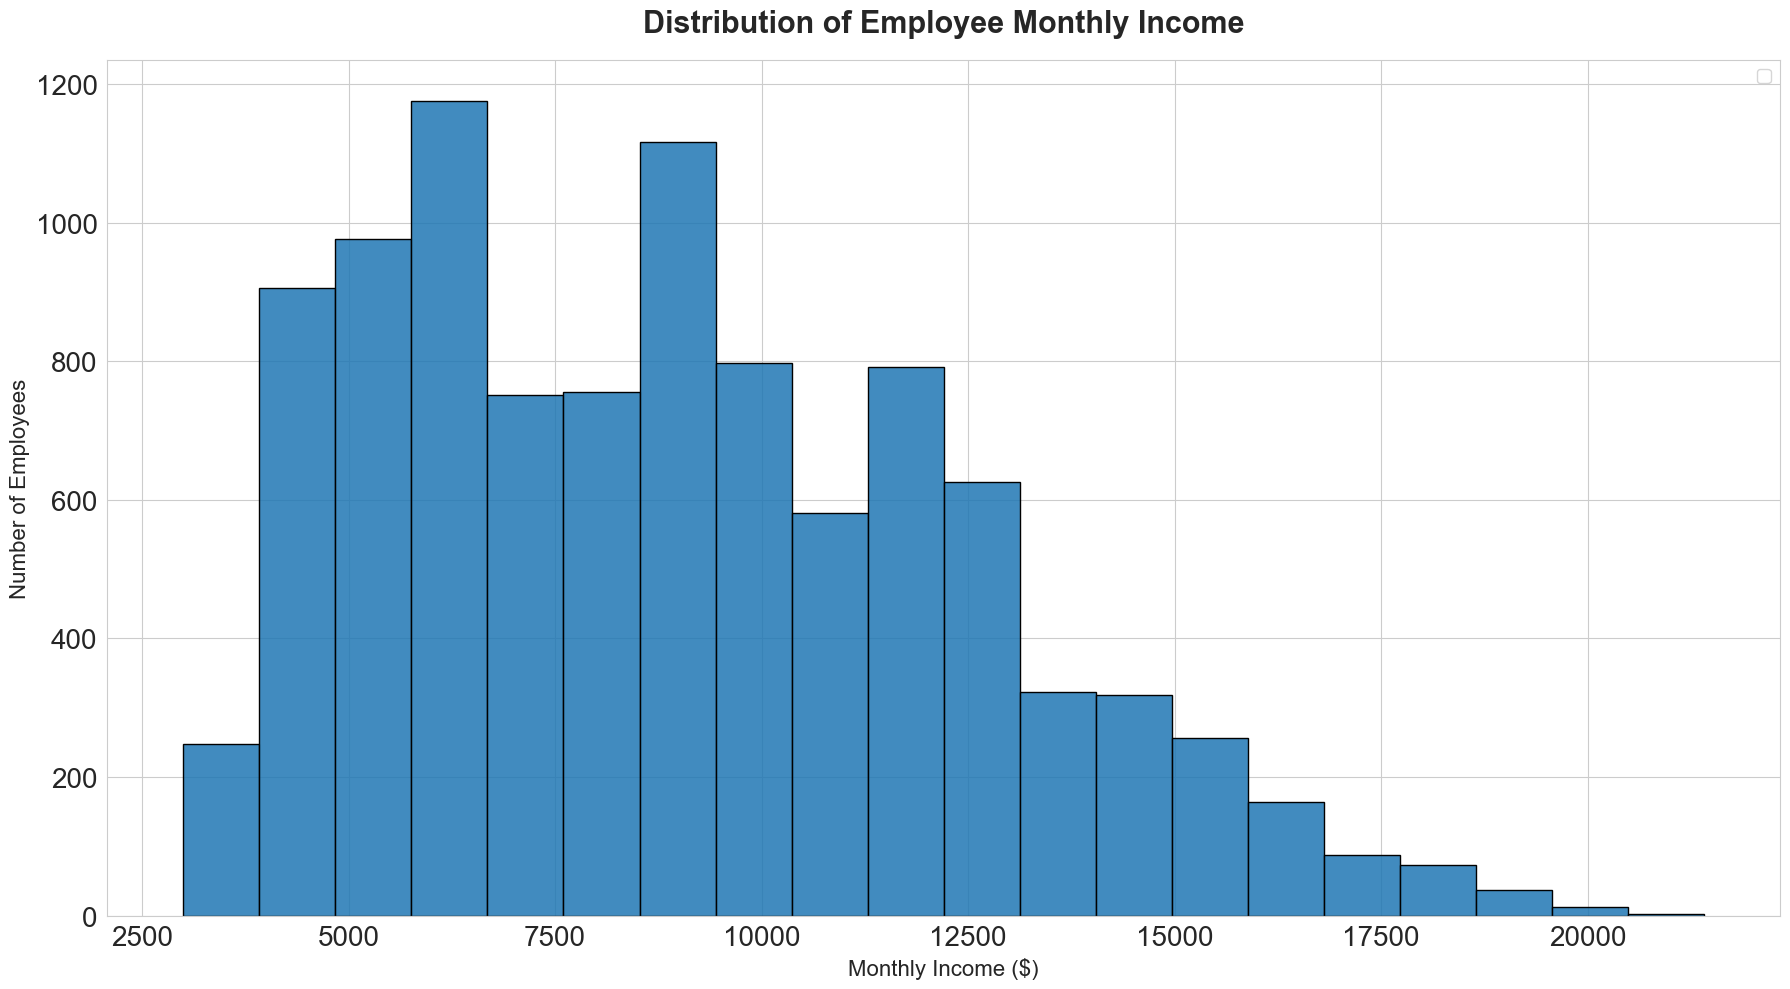

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional style
sns.set_style("whitegrid")

plt.figure(figsize=(18, 10))

ax = sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=20,
    color="#1F77B4",
    edgecolor="black",
    alpha=0.85
)

# Mean income line
mean_income = df["MonthlyIncome"].mean()


# Title and labels
plt.title(
    "Distribution of Employee Monthly Income",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Monthly Income ($)",
    fontsize=16
)

plt.ylabel(
    "Number of Employees",
    fontsize=16
)

# Tick formatting
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)


plt.legend(fontsize=13)

plt.tight_layout()
plt.show()

In [143]:
import pandas as pd

df['MonthlyIncome'].mean()


np.float64(8967.9188)

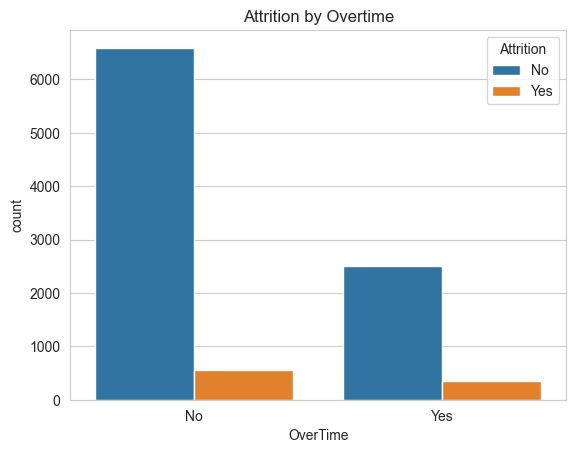

In [49]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition by Overtime")
plt.show()

In [3]:
plt.figure(figsize=(12,6))
sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=45)
plt.show()

NameError: name 'plt' is not defined

In [115]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = label_encoder.fit_transform(df[column])

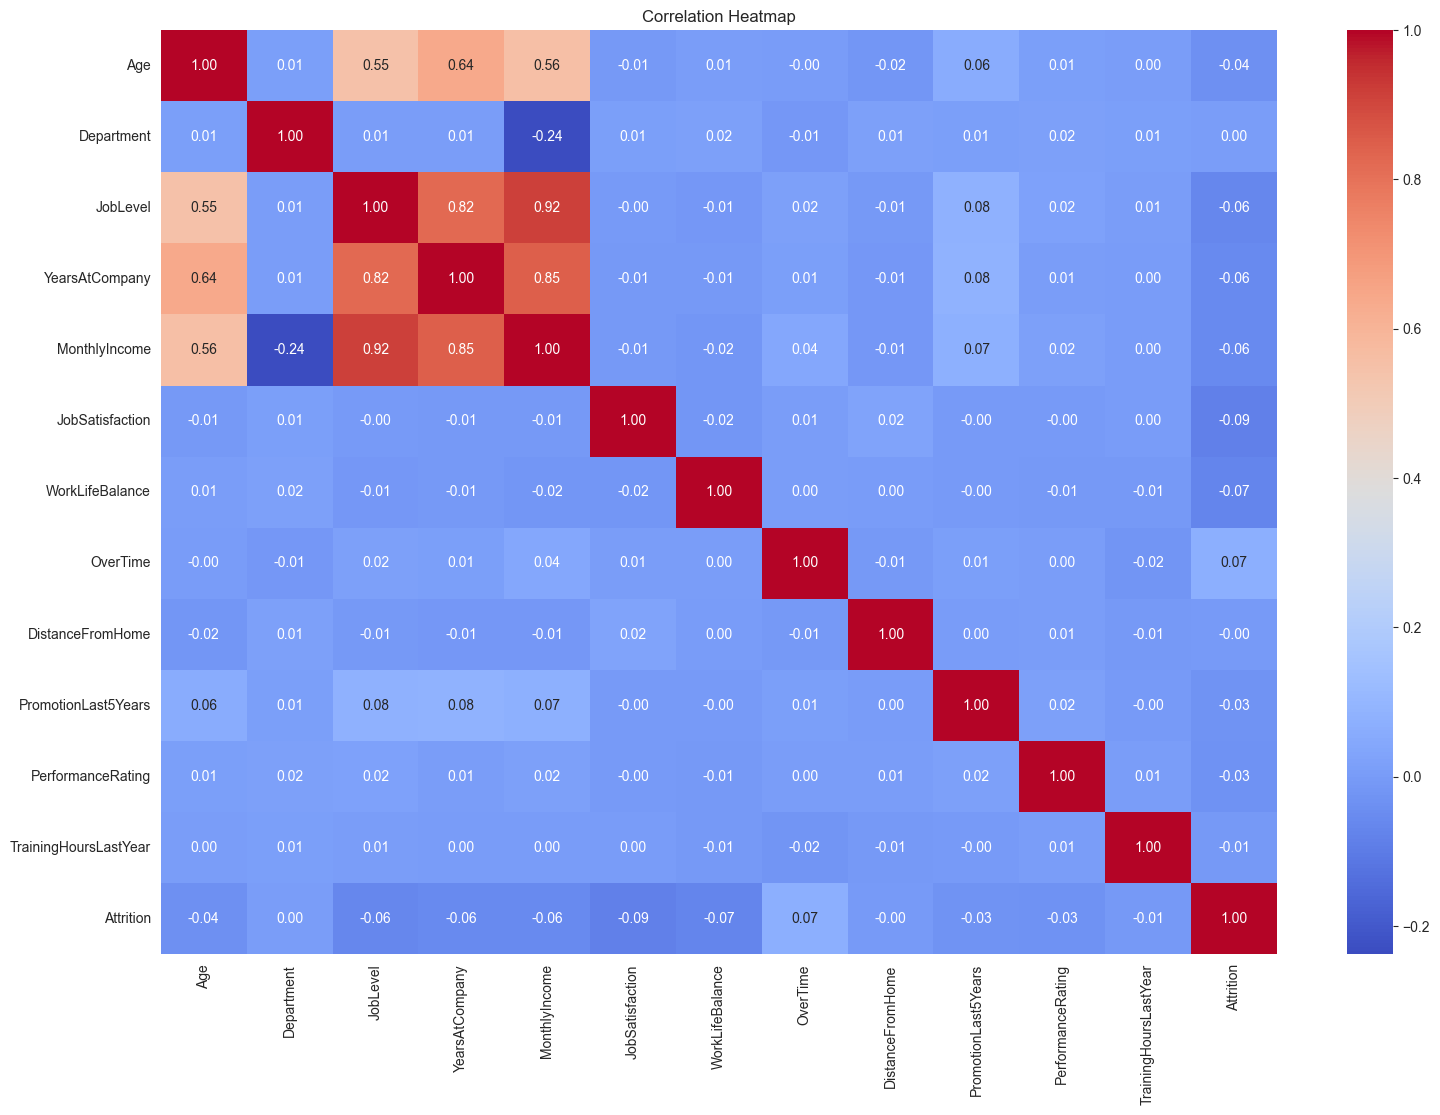

In [116]:
plt.figure(figsize=(18,12))

corr_matrix = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [58]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [126]:
print(X_train.shape)
print(X_test.shape)

(8000, 13)
(2000, 13)


In [127]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [128]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

Accuracy: 0.9065


In [129]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



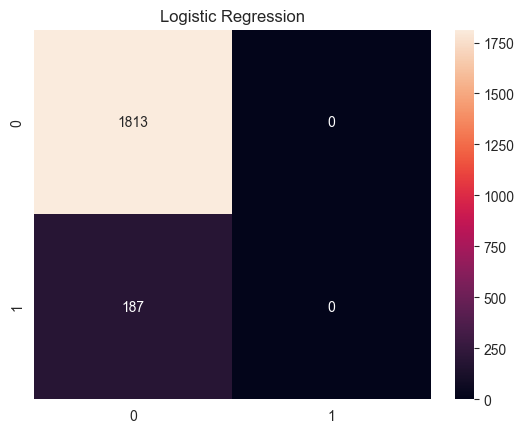

In [130]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression")
plt.show()

In [131]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [132]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

Accuracy: 0.906


In [133]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



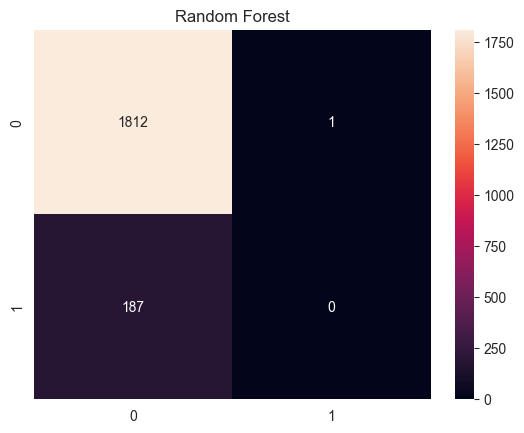

In [134]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest")
plt.show()

In [135]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [136]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,EmployeeID,0.161867
5,MonthlyIncome,0.155364
9,DistanceFromHome,0.145750
1,Age,0.107349
12,TrainingHoursLastYear,0.103236
4,YearsAtCompany,0.082300
2,Department,0.058964
6,JobSatisfaction,0.052671
11,PerformanceRating,0.040186
7,WorkLifeBalance,0.039005


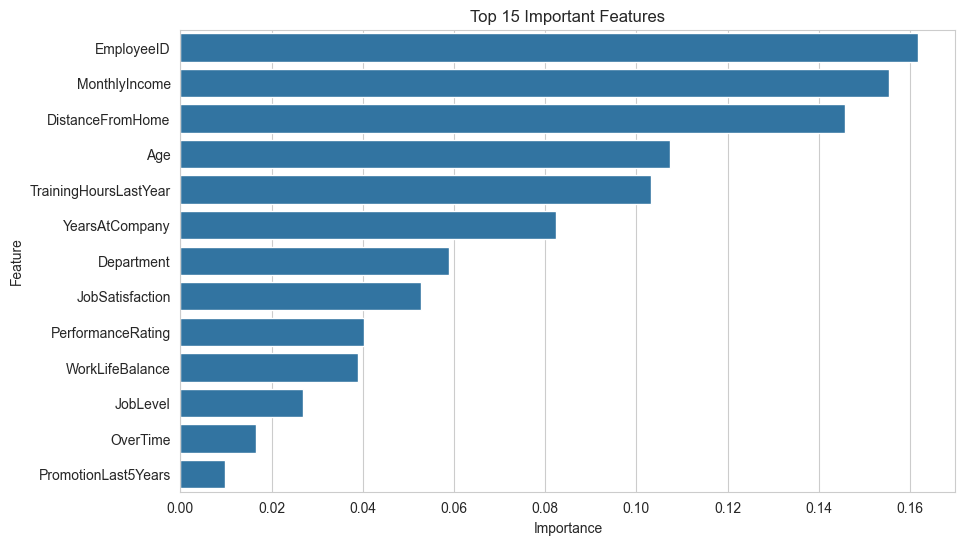

In [139]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")
plt.show()

,Model,Accuracy
0,Logistic Regression,0.9065
1,Random Forest,0.9060


In [83]:
import joblib

joblib.dump(
    rf,
    "employee_attrition_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [123]:
loaded_model = joblib.load(
    "employee_attrition_model.pkl"
)

In [122]:
sample_employee = X.iloc[[0]]

prediction = loaded_model.predict(
    sample_employee
)

print(prediction)

[0]


In [121]:
if prediction[0] == 1:
    print("Employee Likely to Leave")
else:
    print("Employee Likely to Stay")

Employee Likely to Stay


In [120]:
from sklearn.metrics import accuracy_score

predictions = rf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.906


In [88]:
sample_employee = X_test.iloc[[0]]

prediction = rf.predict(sample_employee)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: [0]
Actual: 0


In [89]:
if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to stay


In [90]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

print(results.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        1          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       1          0
17       0          0
18       0          0
19       0          0


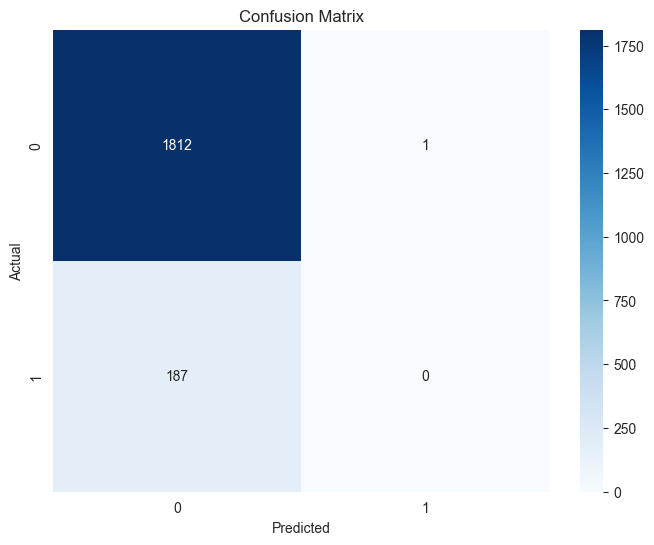

In [91]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [92]:
import joblib

model = joblib.load("employee_attrition_model.pkl")

In [93]:
new_employee = X.iloc[[10]]

prediction = model.predict(new_employee)

print(prediction)

[0]


In [94]:
if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to stay
